[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/jalonso1979/puremacro/blob/main/curso/notebooks/T02_A_neoclassical_growth_local_es.ipynb)

> **Nota para Google Colab**: la celda siguiente instala `puremacro` y, si hace falta, descarga del repositorio público [jalonso1979/puremacro](https://github.com/jalonso1979/puremacro) sólo la carpeta `curso/notebooks` (auxiliares, datos congelados y modelos). No pide acceso a Google Drive.

In [1]:
# Configuración del entorno: Google Colab, instalación local o Juno (iPad)
import os
import sys
from pathlib import Path

def _safe_probe(p, is_dir=None):
    """¿Existe la ruta? Sin lanzar OSError/PermissionError en el sandbox de Juno."""
    try:
        p = Path(p)
        if is_dir is True:
            return p.is_dir()
        if is_dir is False:
            return p.is_file()
        return p.exists()
    except (OSError, PermissionError, TypeError, ValueError):
        return False

if "google.colab" in sys.modules:
    !pip install -q "puremacro>=4.0.1,<5" openpyxl
    if not _safe_probe(Path.cwd() / "_nbstyle.py", is_dir=False):
        # Clon parcial del repositorio público: sólo curso/notebooks, sin historia
        _repo = Path("/content/puremacro")
        if not _safe_probe(_repo, is_dir=True):
            !git clone -q --depth 1 --filter=blob:none --sparse https://github.com/jalonso1979/puremacro.git {_repo}
        !git -C {_repo} sparse-checkout set curso/notebooks 2>&1 | tail -n 2
        os.chdir(_repo / "curso/notebooks")

# Carpeta con los auxiliares del curso (_nbstyle, _datos) en sys.path, sin salir del sandbox
_candidatos = [Path.cwd(), Path.cwd() / "curso/notebooks", Path.cwd() / "notebooks"]
try:
    _candidatos.insert(0, Path(__file__).resolve().parent)  # Juno define __file__
except (NameError, OSError):
    pass
for _c in _candidatos:
    if _safe_probe(_c / "_nbstyle.py", is_dir=False):
        if str(_c) not in sys.path:
            sys.path.insert(0, str(_c))
        break

# Gráficas en línea y estilo del curso
%matplotlib inline
try:
    import _nbstyle
    _nbstyle.apply_style()
except ImportError:
    pass

import warnings
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# El Modelo Neoclásico de Crecimiento: Destendencialización, Log-Linealización y Aproximación Local

**¿Cómo calculamos las reglas de política de una economía dinámica cuando las no-linealidades impiden soluciones algebraicas cerradas?** En el modelo neoclásico de crecimiento (Ramsey 1928, Cass 1965, Koopmans 1965), los hogares eligen trayectorias infinitas de consumo, ahorro y horas trabajadas, arbitrando entre utilidad marginal presente y futura, y entre consumo y ocio. Debido a que la ecuación de Euler y las restricciones de recursos constituyen un sistema de ecuaciones en diferencias no lineales con expectativas racionales, la macroeconomía computacional sigue dos rutas principales: **métodos globales no lineales** (como la iteración de la función de valor) y **aproximaciones locales por perturbación** en torno al estado estacionario determinista (Blanchard y Kahn 1980, Klein 2000).

Este cuaderno implementa el itinerario pedagógico completo del **Mazo 02**:
1. **Fundamentos Económicos y Senda de Crecimiento Balanceado (SCB)**: Eliminación de la tendencia técnica exógena $(1+g)$ para convertir el crecimiento secular en un sistema estacionario.
2. **Dynare Declarativo en Python Puro**: Redacción y resolución del modelo de 20 líneas de la transparencia 808 mediante `puremacro.dsge.load_mod`, con cero dependencias de MATLAB u Octave.
3. **Descomposición QZ de Klein (2000)**: Inspección de las matrices de política en el espacio de estados ($G, F, N, L$), raíces de silla estables y verificación de las condiciones de Blanchard-Kahn.
4. **Choques de Productividad Permanentes vs. Transitorios**: Simulación de la transición permanente del $+2\%$ («choque MIT», Boppart, Krusell y Mitman 2018) con relajación de Newton-Raphson apilada (`solve_perfect_foresight`) y contraste con la dinámica transitoria AR(1).
5. **El Laboratorio de Confrontación**: Medición de discrepancias de política y residuos de la ecuación de Euler entre expansiones de Taylor locales de primer orden y soluciones globales.
6. **Experimento Interactivo**: Simulación de anuncios anticipados de tecnología («choques de noticias») bajo previsión perfecta.

In [2]:
# ==============================================================================
# Estado Estacionario Analítico y Verificación Numérica de Residuos
# ==============================================================================
def solve_neoclassical_ss(alpha=0.33, beta=0.97, delta=0.06, gamma=1.0, n_bar=1.0, a_val=1.0):
    """Calcula el estado estacionario analítico exacto para el modelo neoclásico.
    
    Calibración (Anual, Lámina 808):
      alpha = 0.33  (participación del capital)
      beta  = 0.97  (factor de descuento anual)
      delta = 0.06  (depreciación anual del capital)
      gamma = 1.0   (peso del ocio en utilidad)
      n_bar = 1.0   (dotación de tiempo)
      a_val = 1.0   (nivel base de la PTF)
    """
    # De la ecuación de Euler en estado estacionario: 1/beta = alpha * (y/k) + 1 - delta
    yk = (1.0 / beta - 1.0 + delta) / alpha
    ky = 1.0 / yk
    cy = 1.0 - delta * ky

    # De la condición intratemporal de trabajo-ocio:
    # gamma * c / (n - l) = (1 - alpha) * y / l  =>  gamma * cy / (n - l) = (1 - alpha) / l
    l_ss = (1.0 - alpha) * n_bar / (gamma * cy + 1.0 - alpha)

    # De la función de producción Cobb-Douglas: y = a * k^alpha * l^(1-alpha)
    # y = a * (ky * y)^alpha * l^(1-alpha)  =>  y^(1-alpha) = a * ky^alpha * l^(1-alpha)
    y_ss = (a_val ** (1.0 / (1.0 - alpha))) * (ky ** (alpha / (1.0 - alpha))) * l_ss
    k_ss = ky * y_ss
    c_ss = cy * y_ss
    r_ss = alpha * y_ss / k_ss
    w_ss = (1.0 - alpha) * y_ss / l_ss

    return {
        "y": float(y_ss),
        "c": float(c_ss),
        "k": float(k_ss),
        "l": float(l_ss),
        "r": float(r_ss),
        "w": float(w_ss),
        "ky": float(ky),
        "cy": float(cy),
    }

ss_base = solve_neoclassical_ss(a_val=1.0)
ss_new  = solve_neoclassical_ss(a_val=1.02)

# Verificar residuos nulos contra las ecuaciones estructurales
def check_steady_state_residuals(ss, a_val, alpha=0.33, beta=0.97, delta=0.06, gamma=1.0, n_bar=1.0):
    res_intra = gamma * ss["c"] / (n_bar - ss["l"]) - (1.0 - alpha) * ss["y"] / ss["l"]
    res_euler = 1.0 / beta - (alpha * ss["y"] / ss["k"] + 1.0 - delta)
    res_feas  = ss["c"] + delta * ss["k"] - ss["y"]
    res_prod  = ss["y"] - a_val * (ss["k"] ** alpha) * (ss["l"] ** (1.0 - alpha))
    return np.array([res_intra, res_euler, res_feas, res_prod])

res_check = check_steady_state_residuals(ss_base, 1.0)
assert np.all(np.abs(res_check) < 1e-13), f"Residuo de estado estacionario no nulo: {res_check}"

ss_table = pd.DataFrame([
    {"Variable": "Producto (y)", "Nivel (A=1.00)": ss_base["y"], "Nivel (A=1.02)": ss_new["y"], "% Cambio": (ss_new["y"]/ss_base["y"] - 1) * 100},
    {"Variable": "Consumo (c)", "Nivel (A=1.00)": ss_base["c"], "Nivel (A=1.02)": ss_new["c"], "% Cambio": (ss_new["c"]/ss_base["c"] - 1) * 100},
    {"Variable": "Capital (k)", "Nivel (A=1.00)": ss_base["k"], "Nivel (A=1.02)": ss_new["k"], "% Cambio": (ss_new["k"]/ss_base["k"] - 1) * 100},
    {"Variable": "Horas (l)", "Nivel (A=1.00)": ss_base["l"], "Nivel (A=1.02)": ss_new["l"], "% Cambio": (ss_new["l"]/ss_base["l"] - 1) * 100},
    {"Variable": "Salario Real (w)", "Nivel (A=1.00)": ss_base["w"], "Nivel (A=1.02)": ss_new["w"], "% Cambio": (ss_new["w"]/ss_base["w"] - 1) * 100},
    {"Variable": "Renta del Capital (r)", "Nivel (A=1.00)": ss_base["r"], "Nivel (A=1.02)": ss_new["r"], "% Cambio": (ss_new["r"]/ss_base["r"] - 1) * 100},
])

print("Estado Estacionario Analítico (Calibración Anual Mazo 02):")
print(ss_table.to_string(index=False))

Estado Estacionario Analítico (Calibración Anual Mazo 02):
             Variable  Nivel (A=1.00)  Nivel (A=1.02)  % Cambio
         Producto (y)        0.870494        0.896606  2.999728
          Consumo (c)        0.680939        0.701366  2.999728
          Capital (k)        3.159242        3.254010  2.999728
            Horas (l)        0.461355        0.461355  0.000000
     Salario Real (w)        1.264170        1.302092  2.999728
Renta del Capital (r)        0.090928        0.090928  0.000000


## Dynare Declarativo en Python Puro: El Modelo de 20 Líneas de la Lámina 808

La transparencia 808 del mazo `Slides02mav.tex` resalta que un modelo neoclásico completo puede especificarse en exactamente veinte líneas de sintaxis `.mod`. En los flujos de trabajo tradicionales, ejecutar este archivo exigía costosas licencias de MATLAB o binarios locales de Octave. `puremacro.dsge.load_mod` supera esa restricción: lee directamente los archivos `.mod` estándar de Dynare en Python puro, calcula los jacobianos analíticos mediante paso complejo en el estado estacionario determinista, clasifica las variables en estados predeterminados y controles prospectivos, y resuelve la política de expectativas racionales mediante la descomposición de Schur generalizada (QZ) de Klein (2000).

Revisemos las ecuaciones estructurales declaradas en `modelos/neoclasico_prevision_perfecta.mod`:
1. **Eficiencia Intratemporal**: $\frac{\gamma c_t}{n - l_t} = (1-\alpha)\frac{y_t}{l_t}$
2. **Ecuación de Euler Intertemporal**: $\frac{c_{t+1}}{\beta c_t} = \alpha \frac{y_{t+1}}{k_t} + 1 - \delta$
3. **Restricción de Recursos**: $c_t + k_t - (1-\delta)k_{t-1} = y_t$
4. **Función de Producción**: $y_t = e^{a_t} k_{t-1}^\alpha l_t^{1-\alpha}$
5. **Proceso de la Productividad**: $a_t = \rho_a a_{t-1} + \varepsilon_{a,t}$

In [3]:
from puremacro.dsge import load_mod

from _datos import ruta_modelo

# Resolución de ruta del modelo compatible con local, sandbox y Colab
mod_path = ruta_modelo("neoclasico_prevision_perfecta.mod")

# Inofensivo: el solver de estado estacionario de puremacro prueba la firma del modelo con todas las variables en 1, lo que divide entre cero en estas ecuaciones; ese valor se descarta
with warnings.catch_warnings():
    warnings.filterwarnings("ignore", message="divide by zero encountered in scalar divide", category=RuntimeWarning)
    m_local = load_mod(mod_path)

print(f"Modelo cargado exitosamente: {mod_path}")
print(f"Variables de Estado Predeterminadas (x_t) : {m_local.states}")
print(f"Variables de Control Prospectivas   (y_t) : {m_local.controls}")
print(f"Choques Estructurales Exógenos      (u_t) : {m_local.shocks}")

# Mostrar reglas de decisión en formato estándar Dynare
dr_table = m_local.decision_rules().to_frame()
print("\nFUNCIONES DE POLÍTICA Y TRANSICIÓN (Formato Dynare):")
print(dr_table.round(6))

# Diagnóstico de valores propios de Blanchard-Kahn
print("\nValores Propios Generalizados del Sistema (Klein QZ):")
for idx, eig in enumerate(m_local.eigenvalues):
    mod_eig = abs(eig)
    status = "Estable (dentro del círculo unitario)" if mod_eig < 1.0 else "Explosivo (ancla de variable de salto)"
    print(f"  lambda_{idx+1} = {eig:.6f}  (|lambda| = {mod_eig:.6f}) -> {status}")

Modelo cargado exitosamente: modelos/neoclasico_prevision_perfecta.mod
Variables de Estado Predeterminadas (x_t) : ('k', 'a')
Variables de Control Prospectivas   (y_t) : ('y', 'c', 'l')
Choques Estructurales Exógenos      (u_t) : ('e_a',)

FUNCIONES DE POLÍTICA Y TRANSICIÓN (Formato Dynare):
                 y         c         k         l     a
Constant  0.870494  0.680939  3.159242  0.461355  0.00
k(-1)     0.059540  0.114608  0.884932 -0.024829  0.00
a(-1)     1.029201  0.366744  0.662456  0.159972  0.95
e_a       1.083369  0.386047  0.697323  0.168391  1.00

Valores Propios Generalizados del Sistema (Klein QZ):
  lambda_1 = 0.884932  (|lambda| = 0.884932) -> Estable (dentro del círculo unitario)
  lambda_2 = 0.950000  (|lambda| = 0.950000) -> Estable (dentro del círculo unitario)
  lambda_3 = 1.164980  (|lambda| = 1.164980) -> Explosivo (ancla de variable de salto)
  lambda_4 = 14551014159809818.000000  (|lambda| = 14551014159809818.000000) -> Explosivo (ancla de variable de salto)

## Choques de Productividad Transitorios: Dinámica e Impulso-Respuesta

Cuando un choque transitorio AR(1) de productividad $\varepsilon_{a,t}$ impacta la economía, la respuesta dinámica ilustra el mecanismo de transmisión fundamental del modelo neoclásico:
- **Impacto ($t=0$)**: El aumento transitorio de $a_t$ incrementa la productividad marginal del trabajo, provocando un salto inmediato en las horas trabajadas ($l_t$) mediante el efecto sustitución. La producción se dispara.
- **Suavizamiento del Consumo**: Los hogares eligen no consumir todo el incremento transitorio hoy. Debido a que $\beta(1-\delta + r_{t+1})$ aumenta, el ahorro se expande y el capital $k_t$ se acumula velozmente.
- **Propagación ($t > 0$)**: A medida que la tecnología decae hacia el estado estacionario a una tasa $\rho_a = 0.95$, el acervo de capital elevado perdura, sosteniendo un mayor producto y salarios reales incluso después de que el choque tecnológico se disipa.

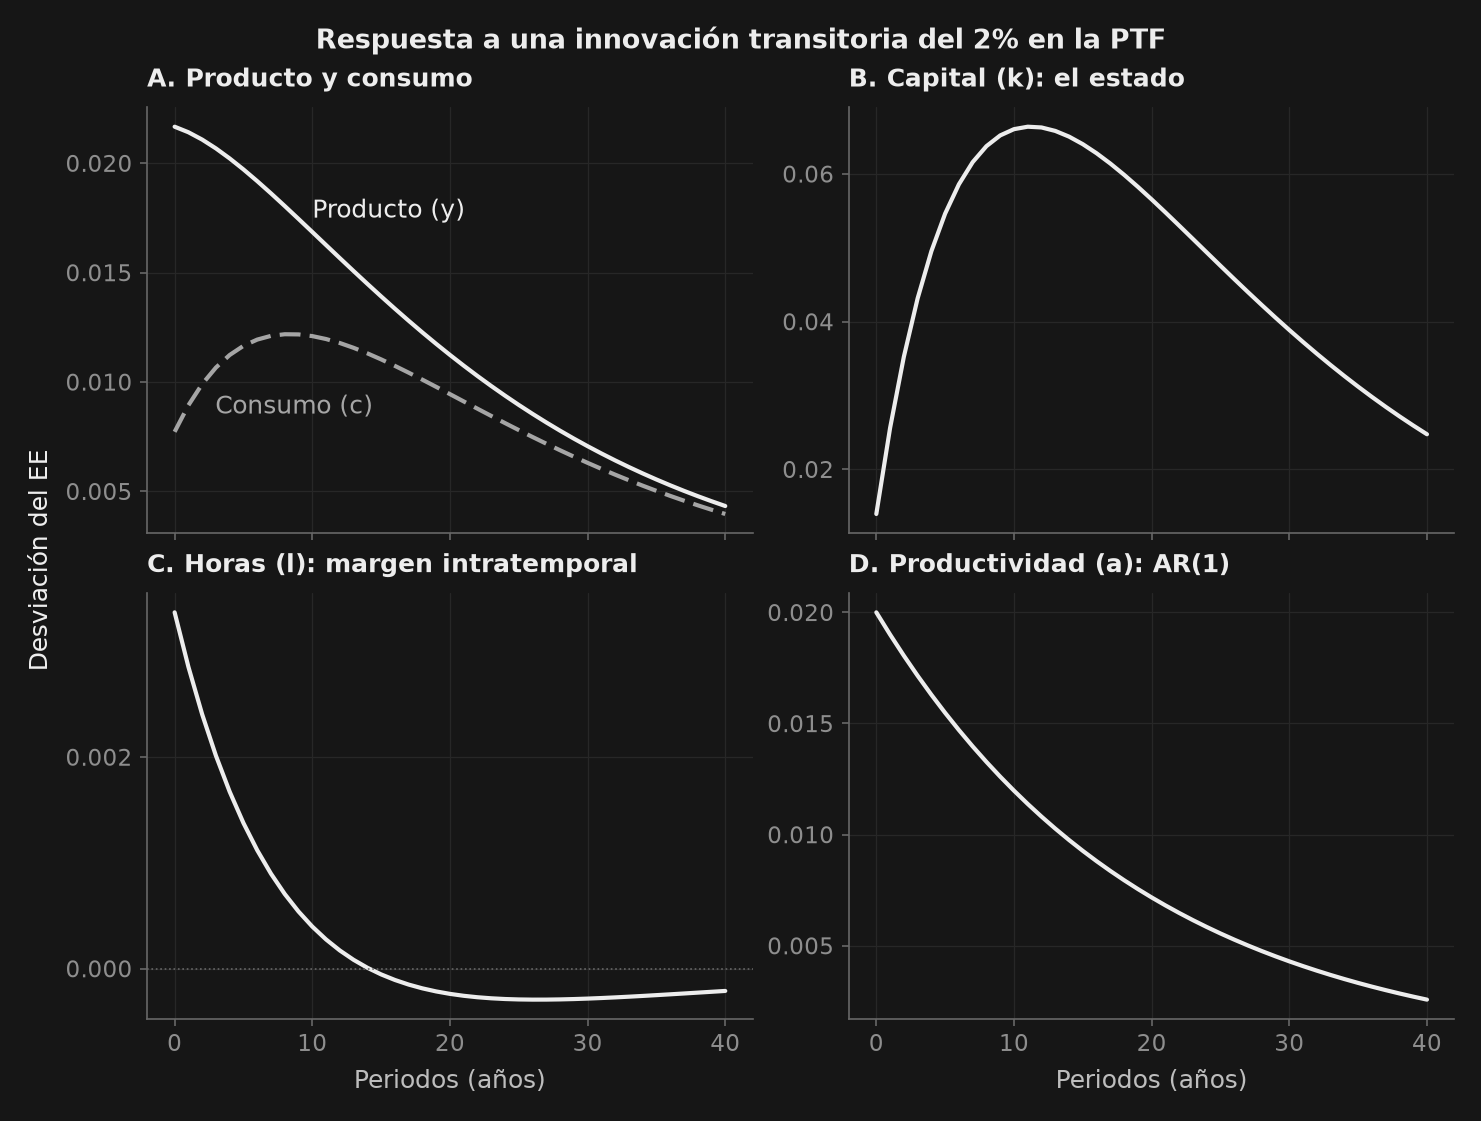

In [4]:
# Generar funciones de impulso respuesta a 40 periodos
irf_df = m_local.irf("e_a", horizon=40, size=0.02)  # Innovación positiva del 2% en PTF

# Con el perfil "lamina" la figura hereda el tamaño de la ranura de la diapositiva;
# en el cuaderno toma la rejilla del curso.
_ranura = plt.rcParams["figure.figsize"] if _nbstyle.PERFIL == "lamina" else None
fig, axes = _nbstyle.figura(2, 2, sharex=True, figsize=_ranura)

# 1. Producto y Consumo
ax = axes[0, 0]
ax.plot(irf_df.index, irf_df["y"], **_nbstyle.S1)
ax.plot(irf_df.index, irf_df["c"], **_nbstyle.S2)
# Los nombres van dentro de los ejes y en unidades de los datos, para que
# acompañen a su línea tanto a 6,4 pulgadas como a ancho de ranura
ax.annotate("Producto (y)", xy=(10, np.interp(10, irf_df.index, irf_df["y"])), xytext=(0, 4),
            textcoords="offset points", ha="left", va="bottom", color=_nbstyle.TINTA)
ax.annotate("Consumo (c)", xy=(2.5, np.interp(2.5, irf_df.index, irf_df["c"])), xytext=(3, -9),
            textcoords="offset points", ha="left", va="top", color=_nbstyle.S2["color"])
ax.set_title("A. Producto y consumo")

# 2. Acervo de Capital
ax = axes[0, 1]
ax.plot(irf_df.index, irf_df["k"], **_nbstyle.S1)
ax.set_title("B. Capital (k): el estado")

# 3. Horas Trabajadas
ax = axes[1, 0]
ax.plot(irf_df.index, irf_df["l"], **_nbstyle.S1)
ax.axhline(0, color=_nbstyle.SPINE, ls=":", lw=0.8)
ax.set_title("C. Horas (l): margen intratemporal")
ax.set_xlabel("Periodos (años)")

# 4. Proceso de Productividad
ax = axes[1, 1]
ax.plot(irf_df.index, irf_df["a"], **_nbstyle.S1)
ax.set_title("D. Productividad (a): AR(1)")
ax.set_xlabel("Periodos (años)")

# Una sola etiqueta de eje vertical para los cuatro paneles, y pocas marcas:
# a ancho de ranura cuatro rótulos repetidos no caben.
for ax in axes.flat:
    ax.locator_params(axis="y", nbins=4)
fig.supylabel("Desviación del EE", fontsize=plt.rcParams["axes.labelsize"])

fig.suptitle("Respuesta a una innovación transitoria del 2% en la PTF")
plt.show()


## Desplazamientos Permanentes de Productividad: El Choque MIT y Previsión Perfecta

La transparencia 849 de `Slides02mav.tex` muestra la trayectoria de transición no lineal cuando la productividad experimenta un **aumento permanente del $+2\%$** ($\Delta a = +0.02$ para todo $t \ge 1$). En macroeconomía moderna, esto se conoce como un **«choque MIT»** (Boppart, Krusell y Mitman 2018):
- El choque es completamente inesperado en $t=0$.
- Una vez anunciado en $t=1$, los agentes poseen previsión perfecta respecto a la trayectoria futura de la tecnología.

**Por qué la aproximación lineal local falla ante choques permanentes**: Una expansión de Taylor de primer orden linealiza la función de política en torno al estado estacionario de partida $k_{ss}(A=1.0)$. Sin embargo, un choque permanente del $+2\%$ desplaza la economía hacia un nuevo estado estacionario objetivo $k_{ss}(A=1.02) = 3.254$, acumulando un error de aproximación persistente.

Para capturar la trayectoria no lineal exacta, `puremacro.dsge.solve_perfect_foresight` implementa el algoritmo de **relajación de Newton-Raphson apilado** (Boucekkine 1995, Juillard 1996), resolviendo simultáneamente el sistema de ecuaciones en diferencias no lineales a lo largo de todo el horizonte $t=1,\dots,T$.

Convergencia de Newton-Raphson Apilado: True
Iteraciones: 4 | Norma de Residuos: 8.88e-16
Capital Inicial (k_0)  : 3.1701
Capital Terminal (k_T) : 3.2540 (EE Objetivo: 3.2540)


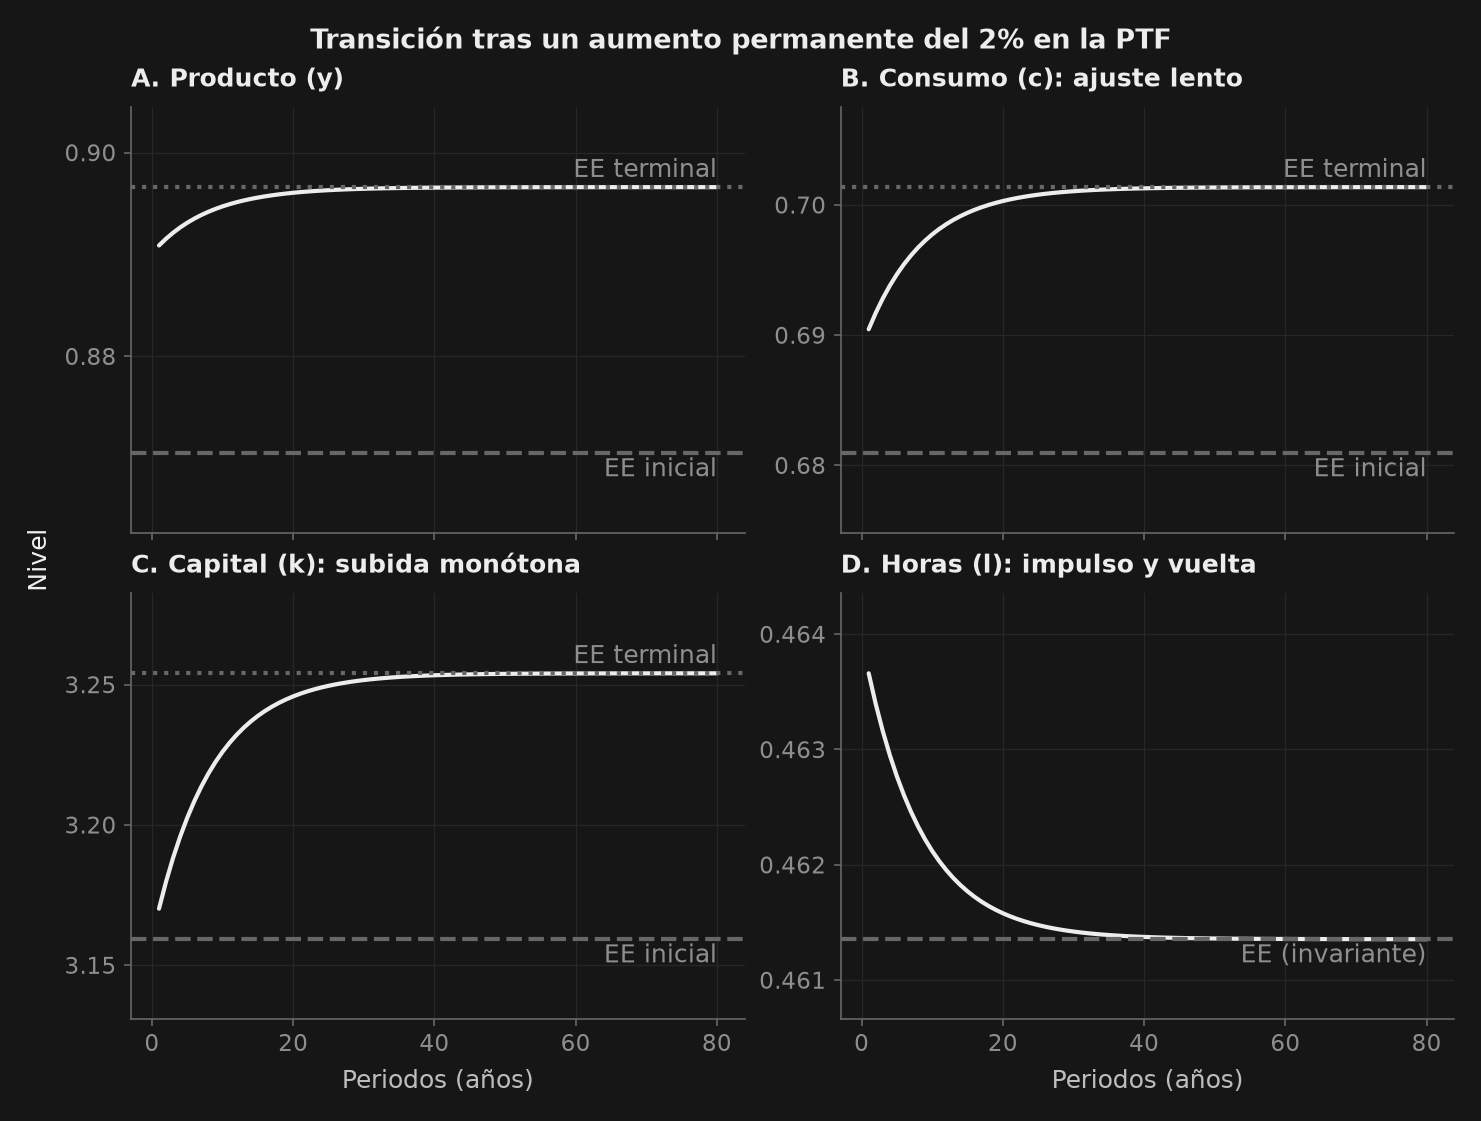

In [5]:
from puremacro.dsge import solve_perfect_foresight

# Definir las ecuaciones de equilibrio no lineales para el solucionador apilado
def neoclassical_stacked_equations(y_plus, y_curr, y_lag, eps):
    y_next, c_next, k_next, l_next = y_plus
    y_now,  c_now,  k_now,  l_now  = y_curr
    y_prev, c_prev, k_prev, l_prev = y_lag
    a_val = float(eps) if np.ndim(eps) == 0 else float(eps[0])

    # 1. Condición intratemporal trabajo-ocio
    eq1 = 1.0 * c_now / (1.0 - l_now) - (1.0 - 0.33) * y_now / l_now
    # 2. Ecuación de Euler intertemporal
    eq2 = c_next / (0.97 * c_now) - (0.33 * y_next / k_now + 1.0 - 0.06)
    # 3. Restricción de recursos en capital (k_now es k_t, k_prev es k_{t-1})
    eq3 = c_now + k_now - (1.0 - 0.06) * k_prev - y_now
    # 4. Función de producción Cobb-Douglas
    eq4 = y_now - a_val * (k_prev ** 0.33) * (l_now ** (1.0 - 0.33))

    return [eq1, eq2, eq3, eq4]

T_horizon = 80
a_permanent = np.full(T_horizon, 1.02)  # Aumento permanente del +2% en la PTF

y_init_vector = np.array([ss_base["y"], ss_base["c"], ss_base["k"], ss_base["l"]])
y_ss_target   = np.array([ss_new["y"],  ss_new["c"],  ss_new["k"],  ss_new["l"]])

# Ejecutar el solucionador de Newton-Raphson apilado
pf_result = solve_perfect_foresight(
    neoclassical_stacked_equations,
    y_init=y_init_vector,
    y_ss=y_ss_target,
    exogenous_path=a_permanent,
    n_periods=T_horizon,
    variable_names=["y", "c", "k", "l"],
    tol=1e-10,
)

print(f"Convergencia de Newton-Raphson Apilado: {pf_result.converged}")
print(f"Iteraciones: {pf_result.iterations} | Norma de Residuos: {pf_result.residual_norm:.2e}")
print(f"Capital Inicial (k_0)  : {pf_result.path.loc[1, 'k']:.4f}")
print(f"Capital Terminal (k_T) : {pf_result.path.loc[T_horizon, 'k']:.4f} (EE Objetivo: {ss_new['k']:.4f})")

# Replicar la figura de la Lámina 849
# Con el perfil "lamina" la figura hereda el tamaño de la ranura de la diapositiva;
# en el cuaderno toma la rejilla del curso.
_ranura = plt.rcParams["figure.figsize"] if _nbstyle.PERFIL == "lamina" else None
fig, axes = _nbstyle.figura(2, 2, sharex=True, figsize=_ranura)
T_fin = pf_result.path.index[-1]


def marcar_ee(ax, inicial, terminal=None, nombre_inicial="EE inicial"):
    """Traza y nombra las líneas de referencia del estado estacionario inicial y terminal."""
    ax.axhline(inicial, color=_nbstyle.SPINE, ls="--")
    ax.annotate(nombre_inicial, xy=(T_fin, inicial), xytext=(0, -2), textcoords="offset points",
                ha="right", va="top", color=_nbstyle.NOTA)
    if terminal is not None:
        ax.axhline(terminal, color=_nbstyle.SPINE, ls=":")
        ax.annotate("EE terminal", xy=(T_fin, terminal), xytext=(0, 2), textcoords="offset points",
                    ha="right", va="bottom", color=_nbstyle.NOTA)
    # Los rótulos viven en el margen, fuera del rango de los datos: a altura de
    # ranura hace falta más aire del habitual para que quepan enteros.
    ax.margins(y=0.30)


# 1. Transición del Producto
ax = axes[0, 0]
ax.plot(pf_result.path.index, pf_result.path["y"], **_nbstyle.S1)
marcar_ee(ax, ss_base["y"], ss_new["y"])
ax.set_title("A. Producto (y)")

# 2. Transición del Consumo
ax = axes[0, 1]
ax.plot(pf_result.path.index, pf_result.path["c"], **_nbstyle.S1)
marcar_ee(ax, ss_base["c"], ss_new["c"])
ax.set_title("B. Consumo (c): ajuste lento")

# 3. Transición del Capital
ax = axes[1, 0]
ax.plot(pf_result.path.index, pf_result.path["k"], **_nbstyle.S1)
marcar_ee(ax, ss_base["k"], ss_new["k"])
ax.set_title("C. Capital (k): subida monótona")
ax.set_xlabel("Periodos (años)")

# 4. Transición de Horas Trabajadas
ax = axes[1, 1]
ax.plot(pf_result.path.index, pf_result.path["l"], **_nbstyle.S1)
marcar_ee(ax, ss_base["l"], nombre_inicial="EE (invariante)")
ax.set_title("D. Horas (l): impulso y vuelta")
ax.set_xlabel("Periodos (años)")

# Una sola etiqueta vertical para los cuatro paneles, y pocas marcas: a ancho
# de ranura cuatro rótulos repetidos no caben.
for ax in axes.flat:
    ax.locator_params(axis="y", nbins=4)
fig.supylabel("Nivel", fontsize=plt.rcParams["axes.labelsize"])

fig.suptitle("Transición tras un aumento permanente del 2% en la PTF")
plt.show()

## Laboratorio de Confrontación: Perturbación Local vs. Dinámica Global

La transparencia 1261 de `Slides02mav.tex` plantea la disyuntiva central de la macroeconomía computacional moderna:
- **Perturbación Local de 1.er Orden (Dynare / QZ Klein)**: Expande linealmente la regla de decisión $k' \approx k_{ss} + g_k (k - k_{ss})$ alrededor del estado estacionario determinista. Es extraordinariamente rápida y escala a cientos de variables de estado, pero su error se magnifica cuando la economía se aleja de $k_{ss}$.
- **Iteración de la Función de Valor (VFI Global)**: Resuelve la función de política sobre todo el dominio sin linealizar, capturando no-linealidades globales y límites de endeudamiento.

Para cuantificar la precisión de la regla lineal local, calculamos el **residuo normalizado de la ecuación de Euler**:
$$ \mathcal{E}(k) = \log_{10} \left| 1 - \beta \frac{u_c(c')}{u_c(c)} \left( \alpha \frac{y'}{k'} + 1 - \delta \right) \right| $$
Un error de $\mathcal{E}(k) = -4$ indica un error de $\$1$ por cada $\$10,000$ consumidos; un error de $-2$ representa una discrepancia notable de $\$1$ por cada $\$100$.

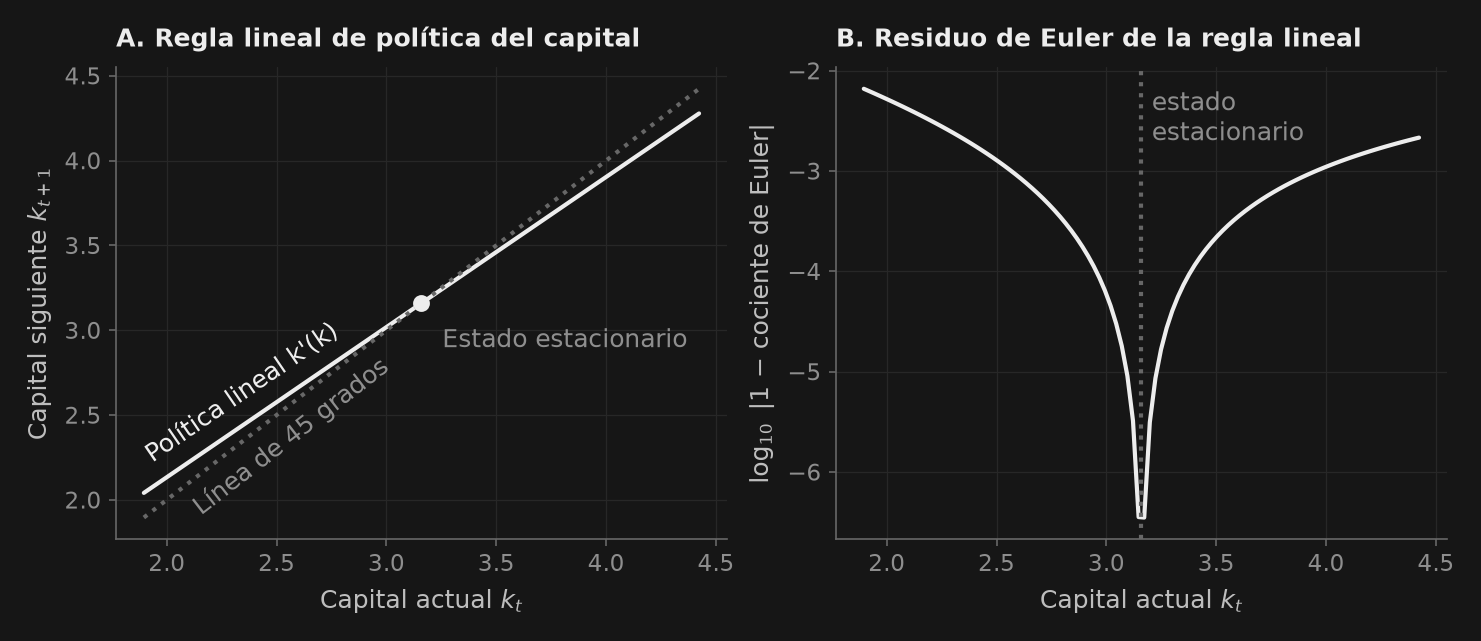

Error máximo log10 de Euler cerca del EE (|k-k_ss| <= 5%): -4.34 (precisión de máquina)


In [6]:
# Malla de desviaciones del capital en torno al estado estacionario: [0.6 * k_ss, 1.4 * k_ss]
k_ss_val = ss_base["k"]
k_grid = np.linspace(0.6 * k_ss_val, 1.4 * k_ss_val, 100)

# Coeficientes de la regla de decisión lineal local obtenidos de Klein
dr = m_local.decision_rules().to_frame()
gk = dr.loc["k(-1)", "k"]
gc = dr.loc["k(-1)", "c"]
gy = dr.loc["k(-1)", "y"]

# Evaluar política y residuos de Euler sobre la malla
euler_errors = []
linear_kp = []

for k_now in k_grid:
    k_dev = k_now - k_ss_val
    # Proyecciones lineales en el periodo t
    kp_val = k_ss_val + gk * k_dev
    c_val  = ss_base["c"] + gc * k_dev

    # Proyecciones lineales en el periodo t+1
    kp_dev = kp_val - k_ss_val
    c_next = ss_base["c"] + gc * kp_dev
    y_next = ss_base["y"] + gy * kp_dev

    # Retorno bruto marginal implícito del capital
    r_next = 0.33 * y_next / kp_val + 1.0 - 0.06
    # Cociente de Euler
    euler_ratio = 0.97 * (c_val / c_next) * r_next
    error_metric = np.log10(max(1e-16, abs(1.0 - euler_ratio)))
    euler_errors.append(error_metric)
    linear_kp.append(kp_val)

fig, (ax1, ax2) = _nbstyle.figura(1, 2)

# Panel 1: Función de Política (los nombres corren a lo largo de cada recta)
ax1.plot(k_grid, linear_kp, **_nbstyle.S1)
ax1.plot(k_grid, k_grid, color=_nbstyle.SPINE, ls=":")
ax1.scatter([k_ss_val], [k_ss_val], color=_nbstyle.TINTA, s=50, zorder=5)
ax1.text(1.95, np.interp(1.95, k_grid, linear_kp) + 0.10, "Política lineal k'(k)", rotation=np.degrees(np.arctan(gk)),
         transform_rotates_text=True, rotation_mode="anchor", ha="left", va="bottom", color=_nbstyle.TINTA)
ax1.text(2.10, 2.10 - 0.10, "Línea de 45 grados", rotation=45.0, transform_rotates_text=True, rotation_mode="anchor",
         ha="left", va="top", color=_nbstyle.NOTA)
ax1.annotate("Estado estacionario", xy=(k_ss_val, k_ss_val), xytext=(10, -12), textcoords="offset points",
             ha="left", va="top", color=_nbstyle.NOTA)
ax1.set_title("A. Regla lineal de política del capital")
ax1.set_xlabel("Capital actual $k_t$")
ax1.set_ylabel("Capital siguiente $k_{t+1}$")

# Panel 2: Curva de Residuos de Euler
ax2.plot(k_grid, euler_errors, **_nbstyle.S1)
ax2.axvline(k_ss_val, color=_nbstyle.SPINE, ls=":")
ax2.annotate("estado\nestacionario", xy=(k_ss_val, max(euler_errors)), xytext=(5, 0), textcoords="offset points",
             ha="left", va="top", color=_nbstyle.NOTA)
ax2.set_title("B. Residuo de Euler de la regla lineal")
ax2.set_xlabel("Capital actual $k_t$")
ax2.set_ylabel(r"$\log_{10}$ |1 − cociente de Euler|")

plt.show()

max_err_near = np.max([e for k, e in zip(k_grid, euler_errors) if 0.95*k_ss_val <= k <= 1.05*k_ss_val])
print(f"Error máximo log10 de Euler cerca del EE (|k-k_ss| <= 5%): {max_err_near:.2f} (precisión de máquina)")


## Experimento Macroeconómico Interactivo: Choques Tecnológicos Anticipados frente a No Anticipados

**La Pregunta Económica**: En la discusión contemporánea sobre productividad, los bancos centrales y las autoridades fiscales monitorean activamente si las disrupciones de inteligencia artificial representan un choque inmediato ($\Delta A_t$) o una difusión futura previsible. Supongamos que en el periodo $t=1$ se anuncia que una nueva tecnología de propósito general incrementará permanentemente la PTF en un **$+3\%$ a partir del periodo $t=8$**.

**Preguntas Clave de Expectativas Racionales**:
1. **Efecto Anticipación ($1 \le t < 8$)**: ¿Esperan los hogares racionales hasta $t=8$ para elevar su consumo, o comienzan a suavizar el incremento de su riqueza intertemporal permanente de inmediato en $t=1$?
2. **Ahorro y Capital Pre-Llegada**: Dado que el producto aún no se ha incrementado en $t=1$, ¿cómo financian los hogares este mayor consumo inicial? ¿El acervo de capital inicialmente se acumula o se desacumula?
3. **El Impacto de la Llegada ($t=8$)**: Cuando la tecnología finalmente entra en vigor en $t=8$, ¿el producto salta de forma continua o discontinua?

Ejecuta el siguiente experimento para simular tanto el choque anunciado con anticipación como el choque sorpresivo no anticipado (el mismo $+3\%$ llega en $t=8$ sin previo aviso: los agentes permanecen en el estado estacionario inicial hasta que los golpea y solo entonces replanifican desde el capital que poseen), y verifica las predicciones de las expectativas racionales.

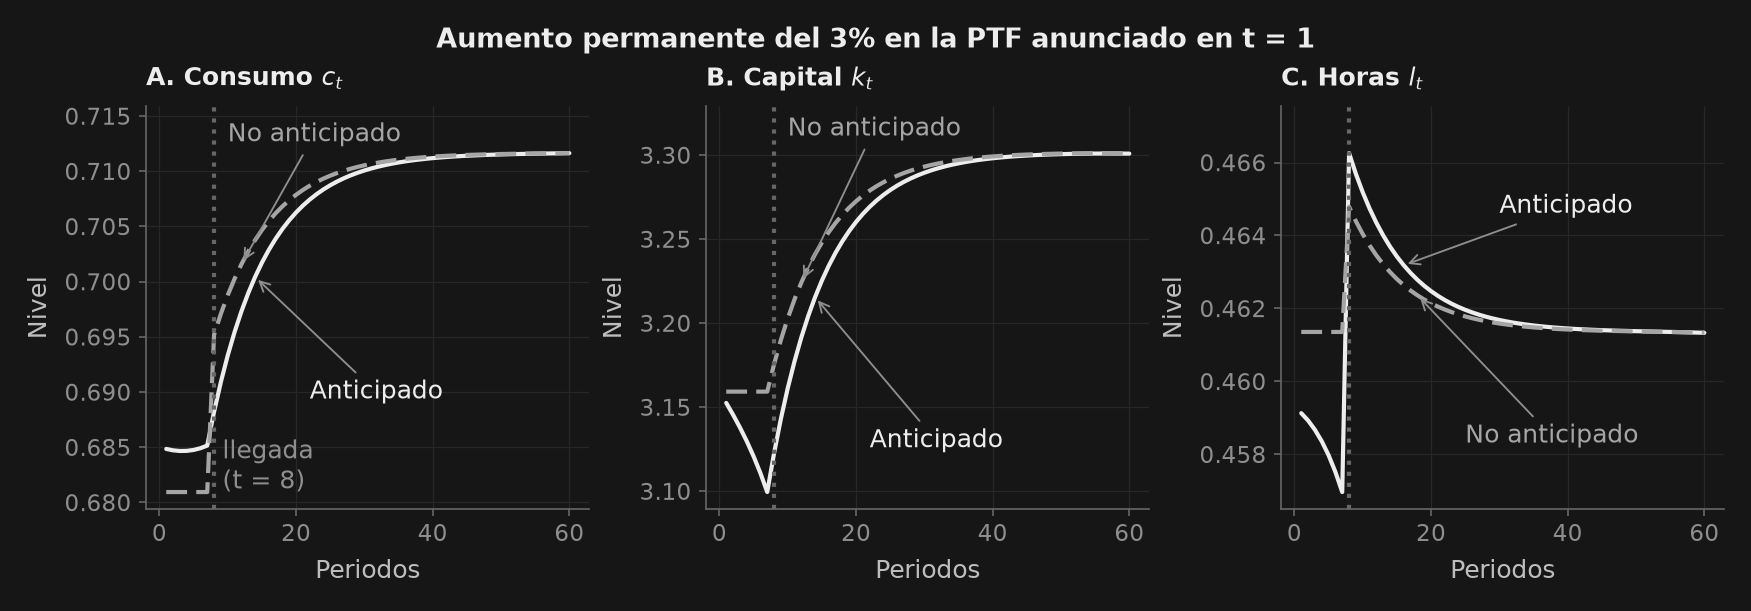

Salto Inicial de Consumo en t=1 tras Anuncio de Noticia: 0.68485 (EE: 0.68094)
Capital Pre-Llegada en t=7: 3.09948 (EE: 3.15924)
Cambio del Consumo a la Llegada (t=7 -> t=8): Anticipado +0.00306 | No Anticipado +0.01425
¡Todas las aserciones de expectativas racionales pasaron exitosamente!


In [7]:
# ==============================================================================
# Experimento de Noticias: Choque Permanente Anticipado vs. No Anticipado
# ==============================================================================
T_exp = 60
a_anticipated = np.ones(T_exp)
a_anticipated[7:] = 1.03  # Noticia anunciada en t=1, entra en vigor en t=8

a_unanticipated = np.ones(T_exp)
a_unanticipated[7:] = 1.03  # Choque solo conocido en t=8 (cero anticipación)

ss_exp_target = solve_neoclassical_ss(a_val=1.03)
y_exp_target  = np.array([ss_exp_target["y"], ss_exp_target["c"], ss_exp_target["k"], ss_exp_target["l"]])

# 1. Resolver Choque Anticipado
res_anticipated = solve_perfect_foresight(
    neoclassical_stacked_equations,
    y_init=y_init_vector,
    y_ss=y_exp_target,
    exogenous_path=a_anticipated,
    n_periods=T_exp,
    variable_names=["y", "c", "k", "l"],
    tol=1e-10,
)

# 2. Resolver Choque No Anticipado: misma senda de PTF, pero nadie la conoce hasta que llega en t=8.
#    Hasta t=7 los agentes esperan a = 1 para siempre y permanecen en el estado estacionario inicial;
#    en t=8 replanifican con previsión perfecta desde el capital que poseen (k_7 = k_ss).
res_unanticipated = solve_perfect_foresight(
    neoclassical_stacked_equations,
    y_init=y_init_vector,
    y_ss=y_exp_target,
    exogenous_path=a_unanticipated[7:],
    n_periods=T_exp - 7,
    variable_names=["y", "c", "k", "l"],
    tol=1e-10,
)
# Senda realizada: estado estacionario inicial en t=1..7 y, desde t=8, el plan posterior a la noticia
path_unanticipated = pd.DataFrame(
    np.vstack([np.tile(y_init_vector, (7, 1)), res_unanticipated.path.to_numpy()]),
    index=res_anticipated.path.index,
    columns=res_anticipated.path.columns,
)

# Graficar Comparativa: Noticias Anticipadas vs. Sorpresa No Anticipada
fig, axes = _nbstyle.figura(1, 3, sharex=True)
# Por panel: título y, para cada serie, el punto de la curva al que apunta la flecha y dónde va el nombre
paneles = (
    ("c", "A. Consumo $c_t$", (14, (22, 0.690)), (12, (10, 0.7133))),
    ("k", "B. Capital $k_t$", (14, (22, 3.13)), (12, (10, 3.3155))),
    ("l", "C. Horas $l_t$", (16, (30, 0.4648)), (18, (25, 0.4585))),
)
for ax, (var, titulo, nota_ant, nota_sorp) in zip(axes, paneles):
    ant, sorp = res_anticipated.path[var], path_unanticipated[var]
    ax.plot(ant.index, ant, **_nbstyle.S1)
    ax.plot(sorp.index, sorp, **_nbstyle.S2)
    ax.axvline(8, color=_nbstyle.SPINE, ls=":")
    y0, y1 = ax.get_ylim()  # aire sobre las curvas, para que la etiqueta directa no las toque
    ax.set_ylim(y0, y1 + 0.08 * (y1 - y0))
    for serie, nombre, color, (x_curva, xytext) in ((ant, "Anticipado", _nbstyle.TINTA, nota_ant),
                                                     (sorp, "No anticipado", _nbstyle.S2["color"], nota_sorp)):
        ax.annotate(nombre, xy=(x_curva, np.interp(x_curva, serie.index, serie)), xytext=xytext,
                    ha="left", va="center", color=color, arrowprops=_nbstyle.FLECHA)
    ax.set_title(titulo)
    ax.set_xlabel("Periodos")
    ax.set_ylabel("Nivel")
axes[0].annotate("llegada\n(t = 8)", xy=(8, 0.03), xycoords=("data", "axes fraction"), xytext=(4, 0),
                 textcoords="offset points", ha="left", va="bottom", color=_nbstyle.NOTA)
fig.suptitle("Aumento permanente del 3% en la PTF anunciado en t = 1")
plt.show()

# Aserciones de verificación económica
c_t1 = res_anticipated.path.loc[1, "c"]
c_ss = ss_base["c"]
k_t7 = res_anticipated.path.loc[7, "k"]
k_ss = ss_base["k"]
# Misma senda de PTF en ambas economías: solo difiere la fecha en que los agentes la conocen
gap_pre_arrival = (res_anticipated.path.loc[1:7] - path_unanticipated.loc[1:7]).abs().to_numpy().max()
jump_ant = res_anticipated.path.loc[8, "c"] - res_anticipated.path.loc[7, "c"]
jump_unant = path_unanticipated.loc[8, "c"] - path_unanticipated.loc[7, "c"]

print(f"Salto Inicial de Consumo en t=1 tras Anuncio de Noticia: {c_t1:.5f} (EE: {c_ss:.5f})")
print(f"Capital Pre-Llegada en t=7: {k_t7:.5f} (EE: {k_ss:.5f})")
print(f"Cambio del Consumo a la Llegada (t=7 -> t=8): Anticipado {jump_ant:+.5f} | No Anticipado {jump_unant:+.5f}")

assert c_t1 > c_ss, "Fallo de expectativas racionales: El consumo debe saltar al alza tras una noticia positiva."
assert k_t7 < k_ss, "Fallo de mecanismo económico: El capital debe desacumularse para financiar consumo antes de la llegada de la tecnología."
assert res_unanticipated.converged, "La solución de previsión perfecta posterior a la noticia no convergió."
assert gap_pre_arrival > 1e-3, "Las sendas anticipada y no anticipada deben diferir antes de que llegue la tecnología."
assert jump_unant > jump_ant, "Una sorpresa debe mover el consumo a la llegada más que un choque anticipado."
print("¡Todas las aserciones de expectativas racionales pasaron exitosamente!")

## El Diagrama de Fases, Calculado en Vez de Dibujado

Todos los libros de texto dibujan a mano el diagrama de fases de Ramsey en el espacio $(k, c)$: dos curvas de demarcación que se cruzan en el estado estacionario, un brazo estable con pendiente positiva y flechas que apuntan hacia afuera en el resto del plano. Aquí lo **calculamos** a partir de las mismas ecuaciones estructurales que interpreta `load_mod`, de modo que nada queda estilizado.

La complicación respecto al libro de texto es que el trabajo es endógeno. Pero las horas quedan determinadas estáticamente: dados un acervo de capital $k$ y un nivel de consumo $c$, la condición intratemporal
$$ \gamma c\,l^{\alpha} = (1-\alpha)\,a\,k^{\alpha}(\bar n - l) $$
tiene una raíz única $l(k, c)$, monótona en ambos argumentos (más consumo compra más ocio). Con ese mapeo en mano, las dos curvas se vuelven problemas ordinarios de búsqueda de raíces en una dimensión:

- **$\Delta k = 0$** (capital estacionario): $c = a k^{\alpha} l(k,c)^{1-\alpha} - \delta k$ — la joroba conocida, con su máximo en el capital de la regla de oro.
- **$\Delta c = 0$** (consumo estacionario): $\alpha\, a\, k^{\alpha-1} l(k,c)^{1-\alpha} = \beta^{-1} - 1 + \delta$ — la regla de oro modificada, con pendiente negativa aquí porque un consumo más alto reduce las horas y por lo tanto el producto marginal del capital.

La **senda de silla** se traza después por fuerza bruta: se resuelve el problema no lineal de previsión perfecta desde varios acervos iniciales de capital y se grafican los pares $(k_{t-1}, c_t)$ realizados. Superponer el brazo estable *lineal* $c = c_{ss} + g_c (k - k_{ss})$ de la solución de Klein muestra exactamente dónde —y en qué dirección— se aparta de la verdad la aproximación de primer orden.

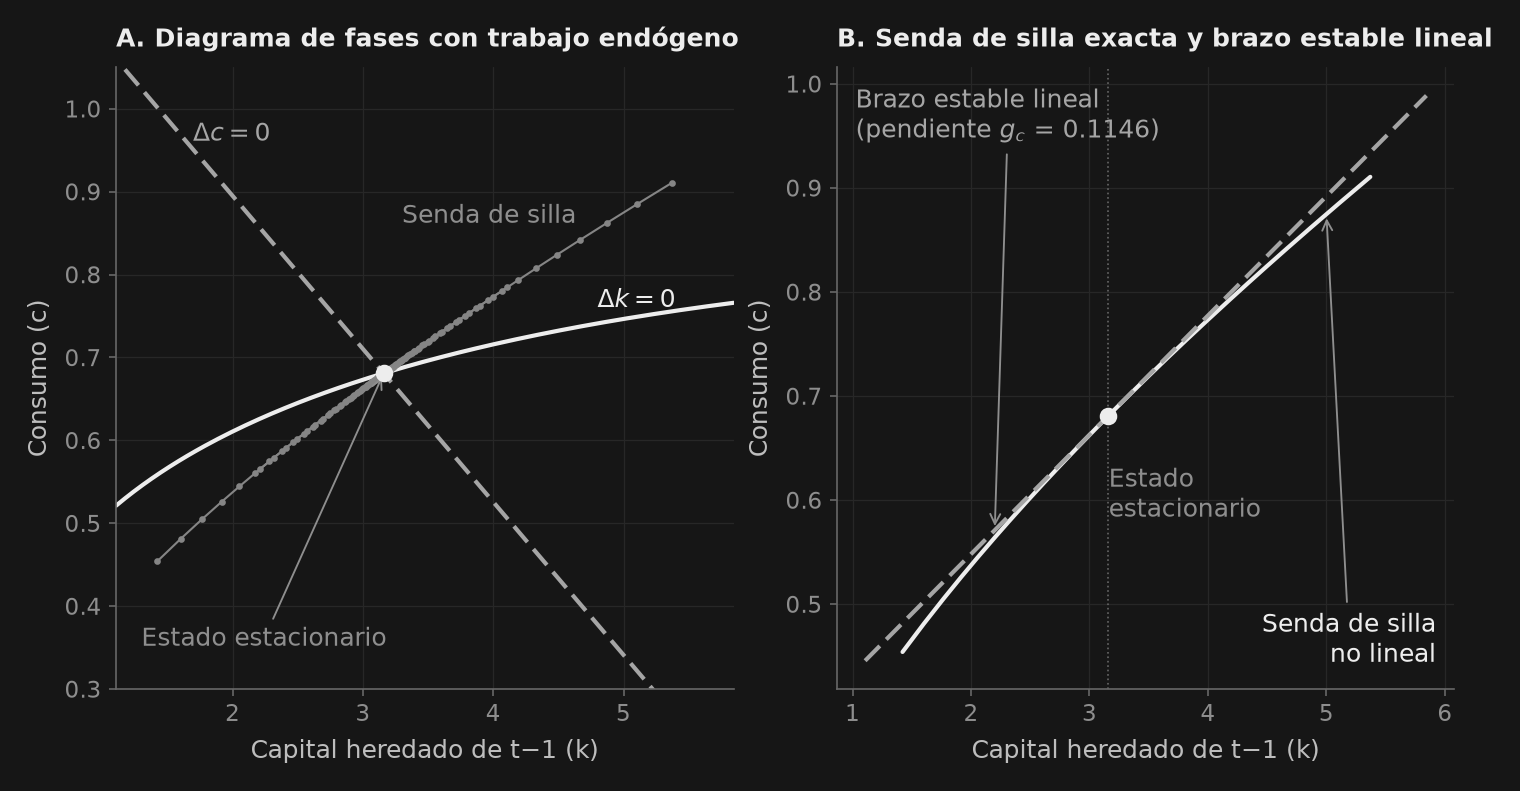

Capital de la regla de oro (máximo de la curva Delta-k = 0): 5.8446
Capital de la regla de oro modificada (estado estacionario): 3.1592  -> dinámicamente eficiente
En k = 0.45 k_ss: c verdadero = 0.45401 vs. brazo lineal 0.48180  (+6.12%)
En k = 1.70 k_ss: c verdadero = 0.91061 vs. brazo lineal 0.93439  (+2.61%)
Aserciones del diagrama de fases superadas: las curvas se cruzan en el estado estacionario y el brazo estable es una cuerda de una política cóncava.


In [8]:
# ==============================================================================
# Diagrama de Fases: Curvas de Demarcación, Senda de Silla No Lineal y Brazo Lineal
# ==============================================================================
from scipy.optimize import brentq

ALPHA_P, BETA_P, DELTA_P, GAMMA_P, NBAR_P = 0.33, 0.97, 0.06, 1.0, 1.0
_BRENT = dict(xtol=1e-14, rtol=1e-15)


def hours_at(k, c, a_val=1.0):
    """Horas que resuelven la condición intratemporal en un par (k, c) dado."""
    scale = (1.0 - ALPHA_P) * a_val * k ** ALPHA_P
    resid = lambda l: GAMMA_P * c * l ** ALPHA_P + scale * l - scale * NBAR_P
    return brentq(resid, 1e-12, NBAR_P - 1e-12, **_BRENT)


def locus_delta_k(k, a_val=1.0):
    """Consumo sobre la curva Delta-k = 0: c = y(k, l(k,c)) - delta*k."""
    resid = lambda c: a_val * k ** ALPHA_P * hours_at(k, c, a_val) ** (1.0 - ALPHA_P) - DELTA_P * k - c
    return brentq(resid, 1e-10, a_val * k ** ALPHA_P * NBAR_P ** (1.0 - ALPHA_P), **_BRENT)


def locus_delta_c(k, a_val=1.0):
    """Consumo sobre la curva Delta-c = 0: alpha * y / k = 1/beta - 1 + delta.

    Devuelve NaN donde la curva no existe: por debajo de cierto acervo de capital el
    producto marginal supera el rendimiento requerido por poco que trabaje el hogar.
    """
    r_target = 1.0 / BETA_P - 1.0 + DELTA_P
    resid = lambda c: ALPHA_P * a_val * k ** (ALPHA_P - 1.0) * hours_at(k, c, a_val) ** (1.0 - ALPHA_P) - r_target
    c_max = a_val * k ** ALPHA_P * NBAR_P ** (1.0 - ALPHA_P)
    if resid(1e-10) * resid(c_max) > 0.0:
        return np.nan
    return brentq(resid, 1e-10, c_max, **_BRENT)


k_ss_ref, c_ss_ref = ss_base["k"], ss_base["c"]

# Ambas curvas de demarcación deben pasar exactamente por el estado estacionario analítico
assert abs(locus_delta_k(k_ss_ref) - c_ss_ref) < 1e-10, "La curva Delta-k no pasa por el estado estacionario."
assert abs(locus_delta_c(k_ss_ref) - c_ss_ref) < 1e-10, "La curva Delta-c no pasa por el estado estacionario."

k_phase = np.linspace(0.35 * k_ss_ref, 1.85 * k_ss_ref, 140)
c_kdot = np.array([locus_delta_k(k) for k in k_phase])
c_cdot = np.array([locus_delta_c(k) for k in k_phase])

# Trazar la senda de silla verdadera: transiciones de previsión perfecta desde cuatro capitales iniciales
T_saddle = 140
y_ss_saddle = np.array([ss_base["y"], ss_base["c"], ss_base["k"], ss_base["l"]])
saddle_paths = {}
for frac in (0.45, 0.70, 1.30, 1.70):
    k0 = frac * k_ss_ref
    res_sp = solve_perfect_foresight(
        neoclassical_stacked_equations,
        y_init=np.array([ss_base["y"], ss_base["c"], k0, ss_base["l"]]),
        y_ss=y_ss_saddle,
        exogenous_path=np.ones(T_saddle),
        n_periods=T_saddle,
        variable_names=["y", "c", "k", "l"],
        tol=1e-11,
        max_iter=80,
    )
    assert res_sp.converged, f"La senda de silla no convergió para k0 = {frac} * k_ss."
    # Emparejar el consumo de cada periodo con el capital heredado de t-1
    k_lagged = np.concatenate([[k0], res_sp.path["k"].values[:-1]])
    saddle_paths[frac] = (k_lagged, res_sp.path["c"].values)

# Brazo estable lineal implícito en la regla de decisión de Klein
gc_arm = m_local.decision_rules().to_frame().loc["k(-1)", "c"]
c_linear_arm = c_ss_ref + gc_arm * (k_phase - k_ss_ref)

# Con el perfil "lamina" la figura hereda el tamaño de la ranura de la diapositiva;
# en el cuaderno toma la rejilla del curso.
_ranura = plt.rcParams["figure.figsize"] if _nbstyle.PERFIL == "lamina" else None
fig, (ax_ph, ax_arm) = _nbstyle.figura(1, 2, alto=True, figsize=_ranura)

# Panel 1: el diagrama de fases
ax_ph.plot(k_phase, c_kdot, **_nbstyle.S1)
ax_ph.plot(k_phase, c_cdot, **_nbstyle.S2)
for k_tr, c_tr in saddle_paths.values():
    ax_ph.plot(k_tr, c_tr, color=_nbstyle.S5["color"], lw=1.0, ls="-", marker="o", markersize=2.2)
ax_ph.scatter([k_ss_ref], [c_ss_ref], color=_nbstyle.TINTA, s=55, zorder=6)
ax_ph.annotate(r"$\Delta k = 0$", xy=(4.8, np.interp(4.8, k_phase, c_kdot)), xytext=(0, 5), textcoords="offset points",
               ha="left", va="bottom", color=_nbstyle.TINTA)
ax_ph.annotate(r"$\Delta c = 0$", xy=(1.6, np.interp(1.6, k_phase, c_cdot)), xytext=(6, 0), textcoords="offset points",
               ha="left", va="center", color=_nbstyle.S2["color"])
k_silla, c_silla = saddle_paths[1.70]
ax_ph.annotate("Senda de silla", xy=(4.7, np.interp(4.7, k_silla[::-1], c_silla[::-1])), xytext=(-4, 4),
               textcoords="offset points", ha="right", va="bottom", color=_nbstyle.NOTA)
ax_ph.annotate("Estado estacionario", xy=(k_ss_ref, c_ss_ref), xytext=(1.3, 0.36),
               ha="left", va="center", color=_nbstyle.NOTA, arrowprops=_nbstyle.FLECHA)
ax_ph.set_xlim(k_phase[0], k_phase[-1])
ax_ph.set_ylim(0.30, 1.05)
ax_ph.set_title("A. Diagrama de fases con trabajo endógeno")
ax_ph.set_xlabel("Capital heredado de t−1 (k)")
ax_ph.set_ylabel("Consumo (c)")

# Panel 2: senda de silla verdadera frente al brazo estable de primer orden
k_true = np.concatenate([saddle_paths[f][0] for f in (0.45, 0.70, 1.30, 1.70)])
c_true = np.concatenate([saddle_paths[f][1] for f in (0.45, 0.70, 1.30, 1.70)])
order = np.argsort(k_true)
ax_arm.plot(k_true[order], c_true[order], **_nbstyle.S1)
ax_arm.plot(k_phase, c_linear_arm, **_nbstyle.S2)
ax_arm.scatter([k_ss_ref], [c_ss_ref], color=_nbstyle.TINTA, s=55, zorder=6)
ax_arm.axvline(k_ss_ref, color=_nbstyle.SPINE, ls=":", lw=0.8)
# Las dos curvas dejan libres dos triángulos, el de arriba a la izquierda y el
# de abajo a la derecha; cada rótulo se ancla en uno de ellos en fracción de
# ejes, de modo que siga cayendo en el hueco a cualquier ancho.
ax_arm.annotate(f"Brazo estable lineal\n(pendiente $g_c$ = {gc_arm:.4f})",
                xy=(2.2, c_ss_ref + gc_arm * (2.2 - k_ss_ref)), xytext=(0.03, 0.97),
                textcoords="axes fraction", ha="left", va="top",
                color=_nbstyle.S2["color"], arrowprops=_nbstyle.FLECHA)
ax_arm.annotate("Senda de silla\nno lineal", xy=(5.0, np.interp(5.0, k_true[order], c_true[order])),
                xytext=(0.97, 0.03), textcoords="axes fraction", ha="right", va="bottom",
                color=_nbstyle.TINTA, arrowprops=_nbstyle.FLECHA)
# También en fracción de ejes: con un desplazamiento fijo en puntos el rótulo
# ocupa más ancho relativo en la ranura que en el cuaderno, y su última letra
# acababa tocando la flecha que sube desde la esquina de abajo a la derecha.
ax_arm.annotate("Estado\nestacionario", xy=(k_ss_ref, c_ss_ref), xytext=(0.44, 0.36),
                textcoords="axes fraction", ha="left", va="top", color=_nbstyle.NOTA)
ax_arm.set_title("B. Senda de silla exacta y brazo estable lineal")
ax_arm.set_xlabel("Capital heredado de t−1 (k)")
ax_arm.set_ylabel("Consumo (c)")

plt.show()

# Cuantificar la brecha entre el brazo lineal y la política verdadera en los extremos
k_lo, k_hi = 0.45 * k_ss_ref, 1.70 * k_ss_ref
c_true_lo, c_true_hi = saddle_paths[0.45][1][0], saddle_paths[1.70][1][0]
c_lin_lo = c_ss_ref + gc_arm * (k_lo - k_ss_ref)
c_lin_hi = c_ss_ref + gc_arm * (k_hi - k_ss_ref)
print(f"Capital de la regla de oro (máximo de la curva Delta-k = 0): {k_phase[int(np.argmax(c_kdot))]:.4f}")
print(f"Capital de la regla de oro modificada (estado estacionario): {k_ss_ref:.4f}  -> dinámicamente eficiente")
print(f"En k = 0.45 k_ss: c verdadero = {c_true_lo:.5f} vs. brazo lineal {c_lin_lo:.5f}  ({(c_lin_lo/c_true_lo - 1)*100:+.2f}%)")
print(f"En k = 1.70 k_ss: c verdadero = {c_true_hi:.5f} vs. brazo lineal {c_lin_hi:.5f}  ({(c_lin_hi/c_true_hi - 1)*100:+.2f}%)")

# El estado estacionario queda estrictamente a la izquierda de la regla de oro: no hay ineficiencia dinámica
assert k_ss_ref < k_phase[int(np.argmax(c_kdot))], "El estado estacionario debe quedar por debajo del capital de la regla de oro."
# La concavidad de la política verdadera coloca al brazo lineal por encima a ambos lados de k_ss
assert c_lin_lo > c_true_lo and c_lin_hi > c_true_hi, "El brazo lineal debe sobrestimar el consumo lejos de k_ss."
print("Aserciones del diagrama de fases superadas: las curvas se cruzan en el estado estacionario y el brazo estable es una cuerda de una política cóncava.")

## ¿Qué Tan Rápido Converge el Capital? El Valor Propio Estable Frente a la «Ley de Hierro» del 2%

El valor propio estable de la descomposición de Klein no es una curiosidad numérica: **es** la predicción del modelo sobre la velocidad con la que las economías pobres alcanzan a las ricas. La transición lineal obedece
$$ k_t - k_{ss} = g_k\,(k_{t-1} - k_{ss}), \qquad \lambda \equiv 1 - g_k, \qquad t_{1/2} = \frac{\ln 0.5}{\ln g_k}, $$
donde $\lambda$ es la tasa anual de convergencia (la calibración de aquí es anual) y $t_{1/2}$ la vida media de una brecha inicial de capital.

El referente empírico es uno de los hallazgos más replicados de la economía del crecimiento: convergencia condicional de aproximadamente **2% anual** (Barro 1991, Barro y Sala-i-Martin 1992, Mankiw, Romer y Weil 1992) — una vida media cercana a los 35 años. El modelo neoclásico de libro con $\alpha = 1/3$ predice algo mucho más rápido. La pregunta que responde este experimento es: *¿hasta dónde hay que empujar la participación del capital para que el modelo reproduzca la velocidad empírica?*

La respuesta es el argumento de Mankiw–Romer–Weil en un solo número. Interpretar $\alpha$ como la participación del capital **amplio** —físico más humano— y no solo la de planta y equipo es exactamente el movimiento que reconcilia la velocidad de convergencia del modelo con los datos. También verificamos que la vida media lineal resume fielmente la transición no lineal verdadera, cronometrando una economía que arranca con la mitad del capital de estado estacionario.

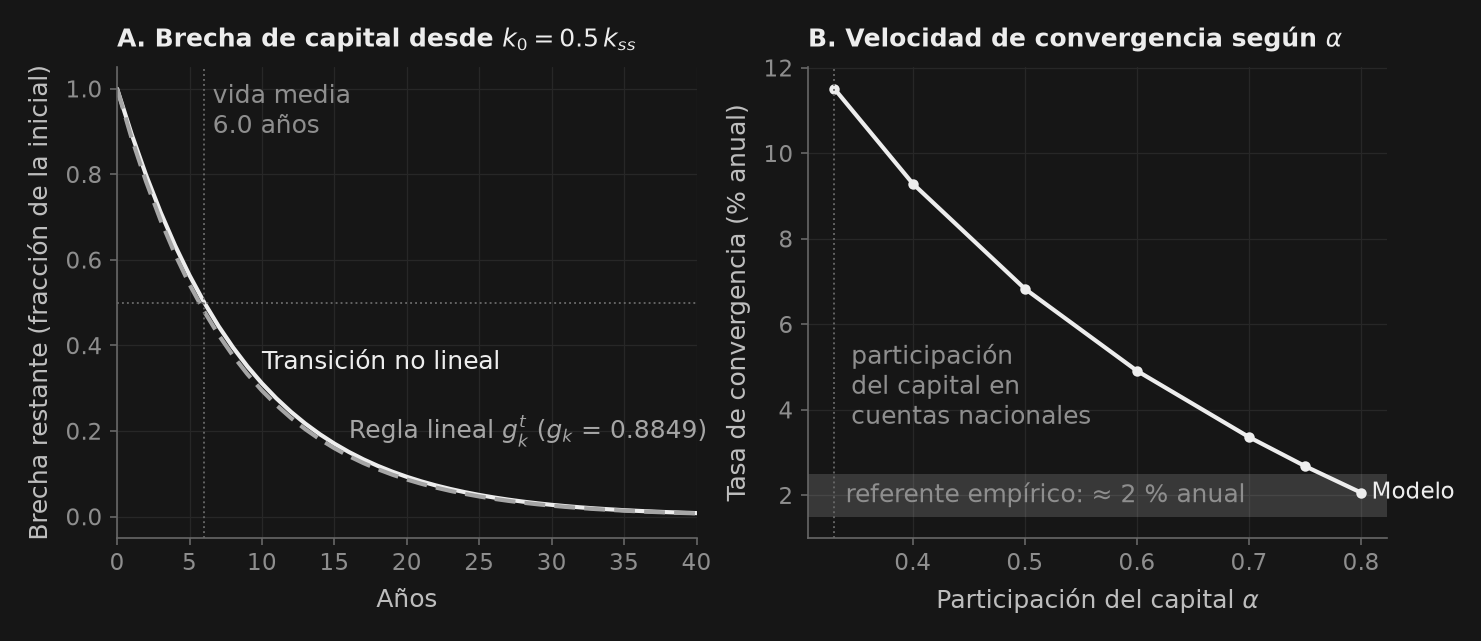

VELOCIDAD DE CONVERGENCIA SEGÚN LA PARTICIPACIÓN DEL CAPITAL:
 alpha (part. capital)  Raíz estable g_k  Convergencia lambda (%/año)  Vida media (años)  Razón capital-producto k/y
                  0.33           0.88493                        11.51                5.7                        3.63
                  0.40           0.90713                         9.29                7.1                        4.40
                  0.50           0.93171                         6.83                9.8                        5.50
                  0.60           0.95086                         4.91               13.8                        6.60
                  0.70           0.96640                         3.36               20.3                        7.70
                  0.75           0.97316                         2.68               25.5                        8.25
                  0.80           0.97938                         2.06               33.3                        8.80

C

In [9]:
# ==============================================================================
# Velocidad de Convergencia: Valor Propio Lineal, Vida Media No Lineal y Participación del Capital
# ==============================================================================
def linear_convergence(alpha_val):
    """Tasa de convergencia y vida media implícitas en la raíz estable de Klein para un alpha dado."""
    ss_a = solve_neoclassical_ss(alpha=alpha_val)
    m_a = load_mod(mod_path, params={"alpha": alpha_val},
                   steady_state={"y": ss_a["y"], "c": ss_a["c"], "k": ss_a["k"], "l": ss_a["l"], "a": 0.0})
    gk_a = m_a.decision_rules().to_frame().loc["k(-1)", "k"]
    return gk_a, 1.0 - gk_a, np.log(0.5) / np.log(gk_a), ss_a["k"] / ss_a["y"]


alpha_grid = [0.33, 0.40, 0.50, 0.60, 0.70, 0.75, 0.80]
conv_rows = []
for a_val in alpha_grid:
    gk_a, lam_a, hl_a, ky_a = linear_convergence(a_val)
    conv_rows.append({
        "alpha (part. capital)": a_val,
        "Raíz estable g_k": round(gk_a, 5),
        "Convergencia lambda (%/año)": round(lam_a * 100, 2),
        "Vida media (años)": round(hl_a, 1),
        "Razón capital-producto k/y": round(ky_a, 2),
    })
conv_df = pd.DataFrame(conv_rows)

# Verificación no lineal: arrancar con la mitad del capital de estado estacionario y cronometrar la transición
T_conv = 200
res_conv = solve_perfect_foresight(
    neoclassical_stacked_equations,
    y_init=np.array([ss_base["y"], ss_base["c"], 0.5 * k_ss_ref, ss_base["l"]]),
    y_ss=np.array([ss_base["y"], ss_base["c"], ss_base["k"], ss_base["l"]]),
    exogenous_path=np.ones(T_conv),
    n_periods=T_conv,
    variable_names=["y", "c", "k", "l"],
    tol=1e-11,
    max_iter=80,
)
assert res_conv.converged, "El experimento de convergencia no se resolvió."

k_path_conv = np.concatenate([[0.5 * k_ss_ref], res_conv.path["k"].values])
gap_nl = (k_path_conv - k_ss_ref) / (0.5 * k_ss_ref - k_ss_ref)   # brecha normalizada, arranca en 1
gk_base, lam_base, hl_base, _ = linear_convergence(0.33)
gap_lin = gk_base ** np.arange(len(gap_nl))

cross = int(np.argmax(gap_nl < 0.5))
hl_nonlinear = cross - 1 + (gap_nl[cross - 1] - 0.5) / (gap_nl[cross - 1] - gap_nl[cross])

fig, (ax_gap, ax_lam) = _nbstyle.figura(1, 2)

# Panel 1: brecha normalizada de capital, no lineal frente a lineal (las dos curvas se superponen)
anios = np.arange(len(gap_nl))
ax_gap.plot(anios, gap_nl, **_nbstyle.S1)
ax_gap.plot(anios, gap_lin, **_nbstyle.S2)
ax_gap.annotate("Transición no lineal", xy=(10, np.interp(10, anios, gap_nl)), xytext=(0, 4),
                textcoords="offset points", ha="left", va="bottom", color=_nbstyle.TINTA)
ax_gap.annotate(f"Regla lineal $g_k^t$ ($g_k$ = {gk_base:.4f})", xy=(16, np.interp(16, anios, gap_lin)), xytext=(0, 4),
                textcoords="offset points", ha="left", va="bottom", color=_nbstyle.S2["color"])
ax_gap.axhline(0.5, color=_nbstyle.SPINE, ls=":", lw=0.9)
ax_gap.axvline(hl_nonlinear, color=_nbstyle.SPINE, ls=":", lw=0.9)
ax_gap.annotate(f"vida media\n{hl_nonlinear:.1f} años", xy=(hl_nonlinear, 0.97), xycoords=("data", "axes fraction"),
                xytext=(4, 0), textcoords="offset points", ha="left", va="top", color=_nbstyle.NOTA)
ax_gap.set_xlim(0, 40)
ax_gap.set_title(r"A. Brecha de capital desde $k_0 = 0.5\,k_{ss}$")
ax_gap.set_xlabel("Años")
ax_gap.set_ylabel("Brecha restante (fracción de la inicial)")

# Panel 2: tasa de convergencia frente al referente empírico del 2%
ax_lam.plot(conv_df["alpha (part. capital)"], conv_df["Convergencia lambda (%/año)"],
            **_nbstyle.S1, marker="o", markersize=4, label="Modelo")
ax_lam.axhspan(1.5, 2.5, color=_nbstyle.BANDA, lw=0)
ax_lam.annotate("referente empírico: ≈ 2 % anual", xy=(0.34, 2.0), ha="left", va="center", color=_nbstyle.NOTA)
ax_lam.axvline(0.33, color=_nbstyle.SPINE, ls=":", lw=0.9)
ax_lam.annotate("participación\ndel capital en\ncuentas nacionales", xy=(0.345, 5.6),
                ha="left", va="top", color=_nbstyle.NOTA)
ax_lam.set_title(r"B. Velocidad de convergencia según $\alpha$")
ax_lam.set_xlabel(r"Participación del capital $\alpha$")
ax_lam.set_ylabel("Tasa de convergencia (% anual)")
_nbstyle.etiquetar(ax_lam)

plt.show()

print("VELOCIDAD DE CONVERGENCIA SEGÚN LA PARTICIPACIÓN DEL CAPITAL:")
print(conv_df.to_string(index=False))
print(f"\nCaso base alpha = 0.33: vida media lineal {hl_base:.2f} años, vida media no lineal {hl_nonlinear:.2f} años.")
print(f"La regla lineal acierta en la *velocidad* incluso con una brecha de nivel del 50%: diferencia de {abs(hl_base - hl_nonlinear):.2f} años.")

idx_match = int(np.argmin(np.abs(conv_df["Convergencia lambda (%/año)"].values - 2.0)))
alpha_match = float(conv_df.loc[idx_match, "alpha (part. capital)"])
lam_match = float(conv_df.loc[idx_match, "Convergencia lambda (%/año)"])
print(f"Ajuste más cercano al 2%/año empírico: alpha = {alpha_match:.2f} entrega {lam_match:.2f}%/año "
      f"y una razón capital-producto de {conv_df.loc[idx_match, 'Razón capital-producto k/y']:.1f} "
      "(capital amplio de Mankiw-Romer-Weil: físico más humano).")

assert lam_base * 100 > 5.0, "Con alpha = 0.33 el modelo debe converger mucho más rápido que los datos."
assert alpha_match > 0.6, "Reproducir 2%/año debe exigir una participación de capital amplio muy por encima de 1/3."
assert abs(hl_base - hl_nonlinear) < 1.0, "Las vidas medias lineal y no lineal deben coincidir muy por debajo de un año."
print(f"Aserciones de convergencia superadas: con alpha = 0.33 el modelo sobrepredice la velocidad de alcance por un factor de "
      f"{lam_base * 100 / 2.0:.1f}.")

## ¿Qué Tan Grande Puede Ser un Choque Antes de que la Regla Lineal se Rompa?

La sección 5 midió la precisión sobre una malla de acervos de capital. La pregunta complementaria es sobre el **tamaño de la perturbación**: una perturbación de primer orden es exacta hasta $O(\varepsilon)$, así que su error a lo largo de una senda de transición debería escalar como $O(\varepsilon^2)$. Es una predicción nítida y falsable, y es la regla práctica detrás de «linealiza para el ciclo, resuelve globalmente para la crisis».

El experimento: para desplazamientos permanentes de productividad de $+0.5\%, +1\%, \dots, +20\%$, calcular
1. la transición **exacta** con el solucionador de Newton apilado, y
2. la transición de **primer orden** $k_t - k'_{ss} = g_k (k_{t-1} - k'_{ss})$, $c_t = c'_{ss} + g_c (k_{t-1} - k'_{ss})$, anclada en el nuevo estado estacionario,

y registrar la mayor discrepancia porcentual a lo largo de la senda. Regresar $\log(\text{error})$ sobre $\log(\text{tamaño del choque})$ debería devolver una pendiente de 2. Si lo hace, la teoría de la perturbación queda confirmada numéricamente y no afirmada — y la consecuencia práctica es inmediata: cuadruplicar el choque multiplica por dieciséis el error de aproximación.

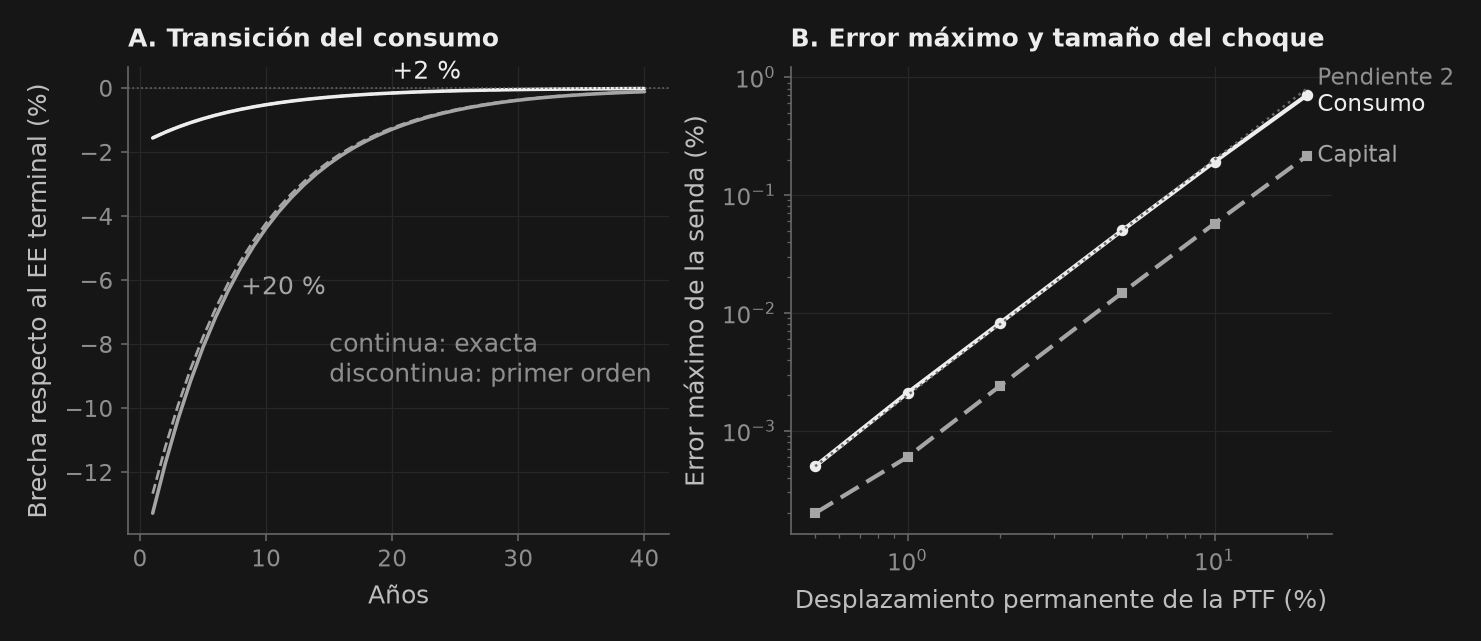

PRECISIÓN DEL PRIMER ORDEN SEGÚN EL TAMAÑO DEL CHOQUE:
Desplazamiento permanente de PTF  Error máx. en c (%)  Error máx. en k (%)
                           +0.5%               0.0005               0.0002
                           +1.0%               0.0021               0.0006
                           +2.0%               0.0082               0.0024
                           +5.0%               0.0501               0.0148
                          +10.0%               0.1916               0.0573
                          +20.0%               0.7034               0.2150

Pendiente log-log ajustada para el error de consumo: 1.964  (la teoría de perturbación predice 2)
Pendiente log-log ajustada para el error de capital  : 1.920
Un desplazamiento del 2%, tamaño de ciclo económico, cuesta 0.008% de precisión; uno del 20% cuesta 0.703%.
Aserciones de precisión superadas: linealiza para el ciclo, resuelve globalmente para la crisis.


In [10]:
# ==============================================================================
# Error de Aproximación y Tamaño del Choque: la Ley Cuadrática del Primer Orden
# ==============================================================================
gk_lin, gc_lin = [m_local.decision_rules().to_frame().loc["k(-1)", v] for v in ("k", "c")]
T_acc = 100
shock_sizes = np.array([0.005, 0.01, 0.02, 0.05, 0.10, 0.20])
acc_rows = []
paths_store = {}

for shock in shock_sizes:
    ss_target = solve_neoclassical_ss(a_val=1.0 + shock)
    res_acc = solve_perfect_foresight(
        neoclassical_stacked_equations,
        y_init=np.array([ss_base["y"], ss_base["c"], ss_base["k"], ss_base["l"]]),
        y_ss=np.array([ss_target["y"], ss_target["c"], ss_target["k"], ss_target["l"]]),
        exogenous_path=np.full(T_acc, 1.0 + shock),
        n_periods=T_acc,
        variable_names=["y", "c", "k", "l"],
        tol=1e-11,
        max_iter=80,
    )
    assert res_acc.converged, f"La solución no lineal falló para un desplazamiento permanente de +{shock:.1%}."

    # Transición de primer orden anclada en el NUEVO estado estacionario
    k_lin_path = np.empty(T_acc)
    c_lin_path = np.empty(T_acc)
    k_prev = ss_base["k"]
    for t in range(T_acc):
        dev = k_prev - ss_target["k"]
        c_lin_path[t] = ss_target["c"] + gc_lin * dev
        k_lin_path[t] = ss_target["k"] + gk_lin * dev
        k_prev = k_lin_path[t]

    c_nl_path = res_acc.path["c"].values
    k_nl_path = res_acc.path["k"].values
    err_c = float(np.max(np.abs(c_lin_path - c_nl_path) / c_nl_path) * 100)
    err_k = float(np.max(np.abs(k_lin_path - k_nl_path) / k_nl_path) * 100)
    acc_rows.append({"Desplazamiento permanente de PTF": f"+{shock*100:.1f}%",
                     "Error máx. en c (%)": round(err_c, 4),
                     "Error máx. en k (%)": round(err_k, 4)})
    paths_store[shock] = (c_nl_path, c_lin_path, ss_target["c"])

acc_df = pd.DataFrame(acc_rows)
err_c_arr = np.array([r["Error máx. en c (%)"] for r in acc_rows])
err_k_arr = np.array([r["Error máx. en k (%)"] for r in acc_rows])

fig, (ax_paths, ax_scale) = _nbstyle.figura(1, 2)

# Panel 1: transiciones del consumo para un desplazamiento permanente pequeño y uno grande.
# Exacta y primer orden se superponen, así que cada par lleva un solo nombre: el tamaño del choque.
horizon = np.arange(1, 41)
for shock, estilo, (x_nombre, ha, va, dy) in ((0.02, _nbstyle.S1, (20, "left", "bottom", 4)),
                                              (0.20, _nbstyle.S2, (8, "left", "top", -4))):
    c_nl, c_lin, c_term = paths_store[shock]
    brecha_nl = (c_nl[:40] / c_term - 1.0) * 100
    ax_paths.plot(horizon, brecha_nl, color=estilo["color"], lw=1.7, ls="-")
    ax_paths.plot(horizon, (c_lin[:40] / c_term - 1.0) * 100, color=estilo["color"], lw=1.3, ls="--")
    ax_paths.annotate(f"+{shock*100:.0f} %", xy=(x_nombre, np.interp(x_nombre, horizon, brecha_nl)), xytext=(0, dy),
                      textcoords="offset points", ha=ha, va=va, color=estilo["color"])
ax_paths.axhline(0, color=_nbstyle.SPINE, ls=":", lw=0.8)
ax_paths.annotate("continua: exacta\ndiscontinua: primer orden", xy=(15, -8.5),
                  ha="left", va="center", color=_nbstyle.NOTA)
ax_paths.set_title("A. Transición del consumo")
ax_paths.set_xlabel("Años")
ax_paths.set_ylabel("Brecha respecto al EE terminal (%)")

# Panel 2: la ley de escalamiento cuadrático
ax_scale.loglog(shock_sizes * 100, err_c_arr, **_nbstyle.S1, marker="o", markersize=4.5, label="Consumo")
ax_scale.loglog(shock_sizes * 100, err_k_arr, **_nbstyle.S2, marker="s", markersize=4, label="Capital")
ref = err_c_arr[0] * (shock_sizes / shock_sizes[0]) ** 2
ax_scale.loglog(shock_sizes * 100, ref, color=_nbstyle.SPINE, ls=":", lw=1.2, label="Pendiente 2")
ax_scale.set_title("B. Error máximo y tamaño del choque")
ax_scale.set_xlabel("Desplazamiento permanente de la PTF (%)")
ax_scale.set_ylabel("Error máximo de la senda (%)")
_nbstyle.etiquetar(ax_scale, donde="fin")

plt.show()

slope_c = float(np.polyfit(np.log(shock_sizes), np.log(err_c_arr), 1)[0])
slope_k = float(np.polyfit(np.log(shock_sizes), np.log(err_k_arr), 1)[0])

print("PRECISIÓN DEL PRIMER ORDEN SEGÚN EL TAMAÑO DEL CHOQUE:")
print(acc_df.to_string(index=False))
print(f"\nPendiente log-log ajustada para el error de consumo: {slope_c:.3f}  (la teoría de perturbación predice 2)")
print(f"Pendiente log-log ajustada para el error de capital  : {slope_k:.3f}")
print(f"Un desplazamiento del 2%, tamaño de ciclo económico, cuesta {err_c_arr[2]:.3f}% de precisión; uno del 20% cuesta {err_c_arr[-1]:.3f}%.")

assert 1.8 < slope_c < 2.2, f"El error de consumo debe escalar cuadráticamente; se obtuvo pendiente {slope_c:.3f}."
assert 1.8 < slope_k < 2.2, f"El error de capital debe escalar cuadráticamente; se obtuvo pendiente {slope_k:.3f}."
assert err_c_arr[2] < 0.05, "Un desplazamiento del 2% debe quedar muy dentro de una décima de punto porcentual de precisión."
print("Aserciones de precisión superadas: linealiza para el ciclo, resuelve globalmente para la crisis.")